# 01.3 — Correlation & Multicollinearity Screening

Phân tích ma trận tương quan Spearman giữa các biến dự báo và sàng lọc hiện tượng đa cộng tuyến qua hệ số phóng đại phương sai (VIF).


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.CorrelationAnalysis import CorrelationAnalyzer

# 1. Nạp dữ liệu Train (Zero Leakage)
df = DataLoader().load_data()
train_df, _ = time_series_split(df)
print(f"📊 Phân tích Tương quan & Đa cộng tuyến (Train Set: {len(train_df):,} ngày x {train_df.shape[1]} cột)")

# 2. Khởi tạo CorrelationAnalyzer
corr_analyzer = CorrelationAnalyzer(train_df, target_col='Lượng mưa', date_col='Ngày')
corr_results = corr_analyzer.analyze()

# 3. Trích xuất bảng kết quả VIF
vif_df = corr_results['multicollinearity_results']
vif_safe = vif_df[vif_df['VIF_Score'] < 10]
vif_high = vif_df[vif_df['VIF_Score'] >= 10]

print(f"\n📊 KẾT QUẢ SÀNG LỌC ĐA CỘNG TUYẾN (VIF SCREENING):")
print(f"   • Tổng số biến khí tượng kiểm tra: {len(vif_df)}")
print(f"   • Số biến đạt chuẩn (VIF < 10):    {len(vif_safe)}")
print(f"   • Số biến bị đa cộng tuyến (VIF>=10): {len(vif_high)}")

print("\n📋 CÁC BIẾN ĐẠT CHUẨN VIF < 10:")
print(vif_safe[['Feature', 'VIF_Score']].to_string(index=False))


📊 Phân tích Tương quan & Đa cộng tuyến (Train Set: 7,060 ngày x 36 cột)
🔍 CORRELATION ANALYZER INITIALIZED
   📊 Dataset Shape: (7060, 36)
   🎯 Target Variable: Lượng mưa
   🔢 Total Features: 35
   📈 Predictor Features: 34

📋 6. CORRELATION ANALYSIS INSIGHTS REPORT

🌤️ 1. METEOROLOGICAL CORRELATION MATRIX ANALYSIS
📊 Meteorological Feature Groups:
   - Temperature: 6 features
   - Humidity: 5 features
   - Wind: 10 features
   - Pressure_Radiation: 11 features
   - Precipitation: 1 features

📅 2. TEMPORAL CORRELATION DYNAMICS

🔍 3. MULTICOLLINEARITY ANALYSIS
📊 Multicollinearity Analysis Results:
                 Feature    VIF_Score    Category Risk_Level
Tốc độ gió tối thiểu 10m 6.594717e+06        Wind       High
        Biên độ nhiệt 2m 5.324709e+06       Other       High
   Nhiệt độ tối thiểu 2m 4.776430e+06 Temperature       High
      Nhiệt độ tối đa 2m 3.491689e+06 Temperature       High
   Tốc độ gió tối đa 10m 3.190071e+06        Wind       High
         Biên độ gió 10m 9.935403

🎨 Trực quan hóa Ma trận Tương quan & Phân cụm đặc trưng:

🔬 4. FEATURE CLUSTERING & PCA ANALYSIS
   📊 Features grouped into 5 clusters:
   Cluster 1: 6 features
   Cluster 4: 6 features
   Cluster 5: 7 features
   Cluster 2: 7 features
   Cluster 3: 8 features
   📈 Principal Components vs Target:
 PC  Explained_Variance  Target_Correlation
PC1               0.369              -0.338
PC2               0.254               0.340
PC3               0.132               0.090
PC4               0.074               0.034
PC5               0.043              -0.036


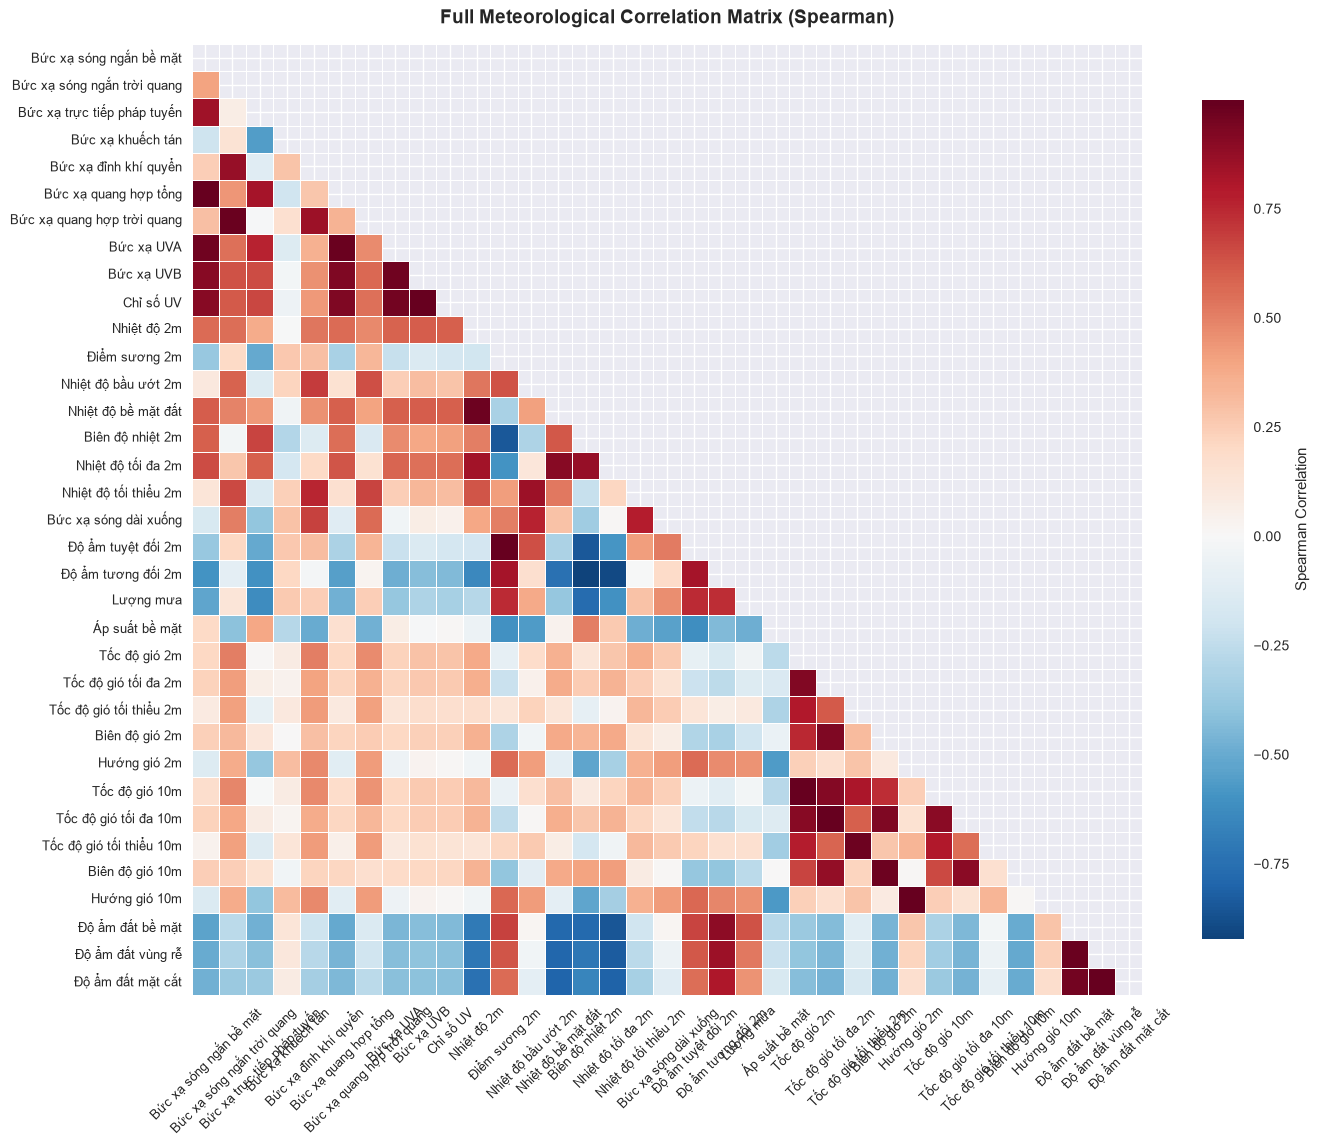

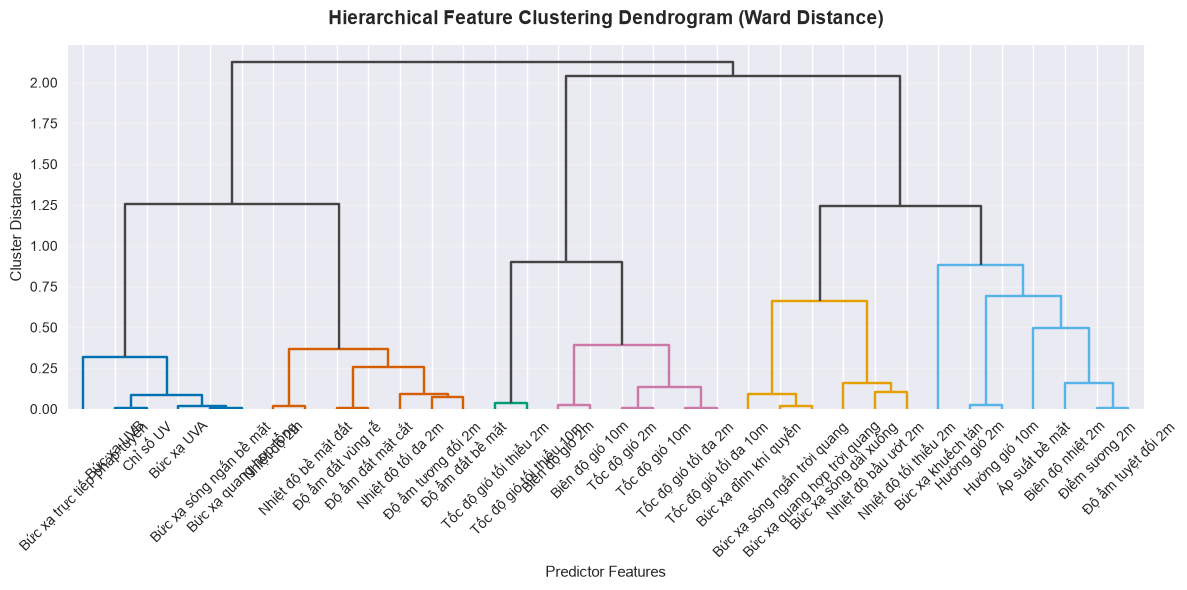

In [2]:
# 4. Trực quan hóa Ma trận Tương quan & Cây Phân cụm
print("🎨 Trực quan hóa Ma trận Tương quan & Phân cụm đặc trưng:")

# 1. Full Spearman Correlation Heatmap
fig_corr = corr_analyzer.plot_full_correlation_matrix(method='spearman', return_fig=True)
plt.show()

# 2. Hierarchical Clustering Dendrogram
fig_dendro = corr_analyzer.plot_dendrogram(return_fig=True)
plt.show()


In [3]:
# 5. Phân tích Chuyên biệt 5 Đặc trưng Bức xạ / UV được giữ lại từ Data Quality
print("=" * 70)
print("☀️ PHÂN TÍCH CHUYÊN BIỆT 5 BIẾN BỨC XẠ / UV ĐƯỢC GIỮ LẠI TỪ DATA QUALITY")
print("=" * 70)

rad_5_cols = [
    "Bức xạ trực tiếp pháp tuyến",
    "Bức xạ quang hợp trời quang",
    "Bức xạ UVA",
    "Bức xạ UVB",
    "Chỉ số UV"
]

# Tương quan Spearman với Target
rad_5_target_corr = {
    col: round(float(train_df['Lượng mưa'].corr(train_df[col], method='spearman')), 4)
    for col in rad_5_cols
}
print("\n🎯 Tương quan Spearman với Lượng mưa của 5 biến bức xạ:")
for col, val in rad_5_target_corr.items():
    print(f"   • {col:<30}: {val:+.4f}")

# Điểm VIF
vif_rad_5 = vif_df[vif_df['Feature'].isin(rad_5_cols)]
print("\n📊 Điểm VIF của 5 biến bức xạ:")
print(vif_rad_5[['Feature', 'VIF_Score', 'Risk_Level']].to_string(index=False))

# Ma trận tương quan chéo giữa 5 biến bức xạ với các biến bức xạ nền tảng khác
all_rad_cols = [c for c in train_df.columns if "Bức xạ" in c or "UV" in c or "quang hợp" in c]
corr_rad_matrix = train_df[all_rad_cols].corr(method='spearman').loc[rad_5_cols].round(3)
print("\n🔗 Tương quan chéo của 5 biến với toàn bộ họ biến bức xạ:")
print(corr_rad_matrix.to_string())

print("      và bảo toàn nguyên vẹn 36 đặc trưng từ 2001-01-01 trở đi (0 missing, 0 gaps).")
print("      (từ 27.2 đến 634.2) và tương quan rất cao (r = 0.84 - 0.99) với các biến bức xạ khác.")


☀️ PHÂN TÍCH CHUYÊN BIỆT 5 BIẾN BỨC XẠ / UV ĐƯỢC GIỮ LẠI TỪ DATA QUALITY

🎯 Tương quan Spearman với Lượng mưa của 5 biến bức xạ:
   • Bức xạ trực tiếp pháp tuyến   : -0.6280
   • Bức xạ quang hợp trời quang   : +0.2444
   • Bức xạ UVA                    : -0.3881
   • Bức xạ UVB                    : -0.3073
   • Chỉ số UV                     : -0.3329

📊 Điểm VIF của 5 biến bức xạ:
                    Feature  VIF_Score Risk_Level
                 Bức xạ UVA 634.193730       High
Bức xạ quang hợp trời quang 576.345006       High
                 Bức xạ UVB 291.318494       High
                  Chỉ số UV 195.198724       High
Bức xạ trực tiếp pháp tuyến  27.240021       High

🔗 Tương quan chéo của 5 biến với toàn bộ họ biến bức xạ:
                             Bức xạ sóng ngắn bề mặt  Bức xạ sóng ngắn trời quang  Bức xạ trực tiếp pháp tuyến  Bức xạ khuếch tán  Bức xạ đỉnh khí quyển  Bức xạ quang hợp tổng  Bức xạ quang hợp trời quang  Bức xạ UVA  Bức xạ UVB  Chỉ số UV  Bức xạ sóng dài 

In [4]:
# 6. Trích xuất độ tương quan với Target variable
target_corr = {}
numeric_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c != 'Lượng mưa']
for col in numeric_cols:
    val = train_df['Lượng mưa'].corr(train_df[col], method='spearman')
    if not np.isnan(val):
        target_corr[col] = round(float(val), 4)

sorted_target_corr = sorted(target_corr.items(), key=lambda x: abs(x[1]), reverse=True)
print("\n🎯 TƯƠNG QUAN SPEARMAN VỚI LƯỢNG MƯA (TOP PREDICTORS):")
for col, val in sorted_target_corr[:10]:
    print(f"   • {col:<30}: {val:+.4f}")

# 7. Xuất Artifact correlation_report.json
OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

corr_artifact = {
    "correlation_method": "Spearman rank correlation",
    "screening_threshold_vif": 10.0,
    "scientific_scope": "EDA-based feature screening, NOT model-specific feature selection. GBDT models retain full feature set; Linear/Statistical models use VIF-filtered features.",
    "total_features_tested": len(vif_df),
    "vif_filtered_features": vif_safe['Feature'].tolist(),
    "high_vif_features": vif_high['Feature'].tolist(),
    "radiation_5_features_analysis": {
        "columns": rad_5_cols,
        "spearman_correlations_with_target": rad_5_target_corr,
        "vif_scores": vif_rad_5[['Feature', 'VIF_Score']].to_dict(orient='records'),
        "scientific_recommendation": "Structural missingness in year 2000 handled in Data Quality by dropping year 2000 rows. EDA shows these 5 features have VIF >= 10 and cross-correlation > 0.84 with existing solar radiation features. Feature Engineering can safely filter them for linear models or retain for tree models."
    },
    "vif_results": vif_df[['Feature', 'VIF_Score']].to_dict(orient='records'),
    "top_spearman_correlations_with_target": dict(sorted_target_corr)
}

artifact_path = OUTPUT_DIR / "correlation_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(corr_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "correlation_report.json", "w", encoding="utf-8") as f:
    json.dump(corr_artifact, f, indent=2, ensure_ascii=False)

print(f"\n💾 Correlation report exported to: {artifact_path}")
print(f"   • Số đặc trưng đạt chuẩn VIF < 10: {len(corr_artifact['vif_filtered_features'])}")



🎯 TƯƠNG QUAN SPEARMAN VỚI LƯỢNG MƯA (TOP PREDICTORS):
   • Biên độ nhiệt 2m              : -0.7692
   • Độ ẩm tuyệt đối 2m            : +0.7410
   • Điểm sương 2m                 : +0.7398
   • Độ ẩm tương đối 2m            : +0.7350
   • Độ ẩm đất bề mặt              : +0.6326
   • Bức xạ trực tiếp pháp tuyến   : -0.6280
   • Nhiệt độ tối đa 2m            : -0.6035
   • Độ ẩm đất vùng rễ             : +0.5217
   • Bức xạ sóng ngắn bề mặt       : -0.5210
   • Áp suất bề mặt                : -0.4868

💾 Correlation report exported to: D:\DS108_project\notebooks\eda\outputs\correlation_report.json
   • Số đặc trưng đạt chuẩn VIF < 10: 3
